# CMIP6 quickstart — a bbox/time `tas` subset from the raw archive

`earthlens.cmip6` exposes the **full raw CMIP6 archive** — the whole
`model × scenario × variable × member` matrix — as analysis-ready Zarr on the
open Pangeo `gs://cmip6` bucket. Unlike the `gee` backend's single
pre-downscaled `NASA/GDDP-CMIP6` product, or the CHC-CMIP6 precipitation
deltas, this reaches every ESM on its native grid.

This is a **live, anonymous** pull — no credentials. We resolve one store
(model `CanESM5`, scenario `ssp585`, variable `tas`, monthly table `Amon`) and
have **pyramids** write a small Europe / half-year NetCDF subset, then plot it.

## Setup

`EarthLens` is the unified entry point; `earthlens.cmip6.Catalog` is the
config + curated-vocabulary catalog. `tempfile` / `pathlib` give us a scratch
directory for the written NetCDF.

In [1]:
import tempfile
from pathlib import Path

from earthlens.core import EarthLens
from earthlens.cmip6 import Catalog

## Explore the catalog (no network)

The bundled catalog carries the consolidated-stores CSV URL plus a curated
vocabulary of common variables, experiments, and tables. Resolution runs
against the full CSV, so uncurated facets still download — the curated rows
just enrich metadata and error messages.

In [2]:
cat = Catalog()
print('variable :', cat.get_dataset('tas').long_name, '(', cat.get_dataset('tas').units, ')')
print('scenario :', 'ssp585 ->', cat.get_experiment('ssp585').description)
print('table    :', 'Amon ->', cat.get_table('Amon').description)
print('CSV index:', cat.csv_url)

variable : Near-surface (2 m) air temperature ( K )
scenario : ssp585 -> SSP5-8.5 — very high emissions, fossil-fuelled growth.
table    : Amon -> Monthly-mean atmospheric fields.
CSV index: https://storage.googleapis.com/cmip6/pangeo-cmip6.csv


## Build and run the request

The request is a CMIP6 **facet tuple** plus a date window and a bounding box.
We crop the native grid to Europe and the window to the first half of 2050, so
pyramids fetches only those cells. `download()` returns the `list[Path]` of
written NetCDF subsets — one per resolved store.

In [3]:
out_dir = Path(tempfile.mkdtemp(prefix='cmip6_'))
paths = EarthLens(
    'cmip6',
    source_id='CanESM5',
    experiment_id='ssp585',
    variable_id='tas',
    table_id='Amon',
    member_id='r1i1p1f1',
    start='2050-01-01',
    end='2050-06-30',
    lat_lim=[35.0, 60.0],
    lon_lim=[-10.0, 30.0],
    path=str(out_dir),
).download(progress_bar=False)
paths

2026-07-05 13:43:47 | INFO | pyramids.base.config | Logging is configured.


[WindowsPath('C:/Users/main/AppData/Local/Temp/cmip6_vdj4q1mf/CanESM5_ssp585_tas_Amon_r1i1p1f1_gn_v20190429_20500101_20500630.nc')]

## Inspect the written NetCDF

The read is entirely **pyramids'** (GDAL `/vsigs/`) — earthlens never imports
`xarray` / `zarr` / `gcsfs`. The output carries one band per monthly timestep
in the window (six bands for January–June 2050).

In [4]:
from pyramids.netcdf import NetCDF

nc = NetCDF.read_file(str(paths[0]))
print('bands (monthly steps):', len(nc.variable_names))
print(nc.variable_names)

bands (monthly steps): 6
['Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6']


## Plot the first month with pyramids

Each band is a georeferenced grid on CanESM5's native resolution. We pull the
first month and plot it with pyramids (via cleopatra).

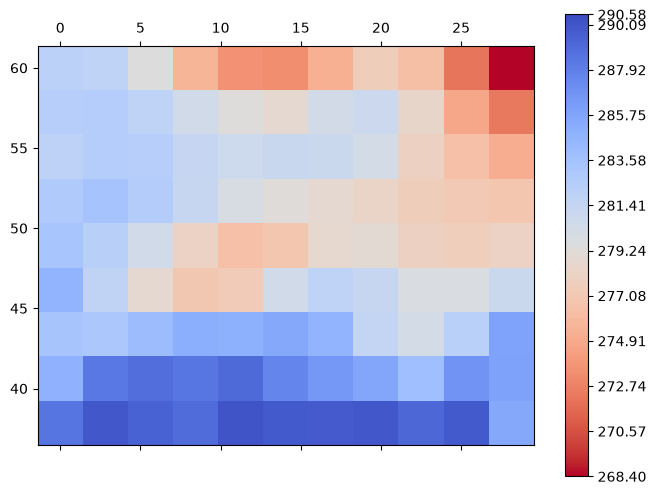

In [5]:
tas_jan = NetCDF.read_file(str(paths[0])).get_variable('Band1')
tas_jan.plot()

## Attribution

CMIP6 output is provided for research under each source model's terms (most are
CC BY 4.0). Always **cite the source GCM**; the backend surfaces the per-model
note.

In [6]:
backend = EarthLens(
    'cmip6', source_id='CanESM5', experiment_id='ssp585', variable_id='tas',
    table_id='Amon', start='2050-01-01', end='2050-06-30',
    lat_lim=[35.0, 60.0], lon_lim=[-10.0, 30.0], path=str(out_dir),
).datasource
print(backend.terms_note())

CC BY 4.0 — cite CanESM5 (Swart et al., 2019).
